# 03 — Exploração e Tratamento de Séries

## Objetivo

Analisar visualmente cada série macroeconômica e tomar decisões sobre dessazonalização, 
transformações logarítmicas e tratamento da pandemia, gerando o dataset final para 
modelagem em `data/processed/`.

## Dados de entrada

`data/raw/series_macroeconomicas.csv` — gerado pelo notebook `02_ingestao.ipynb`. 
Frequência mensal, janela 2000-01 a 2025-12.

## Decisões metodológicas

- **Dessazonalização**: aplicada apenas a séries que apresentem padrão sazonal claro, 
  via X-13 ARIMA-SEATS.
- **Transformação log**: aplicada a séries em níveis (preços, índices), preservando 
  séries já em variação percentual (IPCA, Selic, expectativa de inflação).
- **Pandemia**: dummies mensais para março/2020 a setembro/2020 (período de maior 
  distorção), a ser confirmado por análise visual.

## Outputs

- `data/processed/series_tratadas.csv` — séries finais
- `outputs/figures/01_series_nivel.png` — visão geral
- `outputs/figures/02_*.png` — gráficos diagnósticos por série

## 1. Carregamento dos dados

Carregamos o CSV consolidado no notebook anterior.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configurações
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')

# Carrega o CSV salvo no Bloco 2
df = pd.read_csv(
    DATA_RAW / 'series_macroeconomicas.csv',
    index_col=0,
    parse_dates=True
)

print(f"Shape: {df.shape}")
print(f"Período: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")
df.head()

Shape: (312, 9)
Período: 2000-01 a 2025-12


,ibcbr,ipca,selic,cambio,commodities,m1,prod_industrial,credito_total,exp_ipca_12m
Date,,,,,,,,,
2000-01-01,NaN,0.62,18.94,1.8037,51.41,NaN,NaN,289197,NaN
2000-02-01,NaN,0.13,18.87,1.7753,50.22,NaN,NaN,287573,NaN
2000-03-01,NaN,0.22,18.85,1.7420,49.51,NaN,NaN,286084,NaN
2000-04-01,NaN,0.42,18.62,1.7682,50.31,NaN,NaN,291609,NaN
2000-05-01,NaN,0.01,18.51,1.8279,53.18,NaN,NaN,312232,NaN


## 2. Análise visual em nível

Antes de qualquer teste estatístico, inspecionamos cada série visualmente. 
Boa parte dos problemas em séries temporais (outliers, quebras estruturais, 
sazonalidade, mudanças de regime) é detectável a olho nu e mais confiável 
do que testes formais aplicados às cegas.

Procuramos:

- **Tendência**: persistência de movimento crescente ou decrescente
- **Sazonalidade**: padrão que se repete a cada 12 meses
- **Quebras estruturais**: saltos súbitos não-recorrentes
- **Mudanças de regime**: alteração na volatilidade ou no nível médio
- **Outliers**: pontos anômalos isolados, especialmente em torno da pandemia (2020-21)

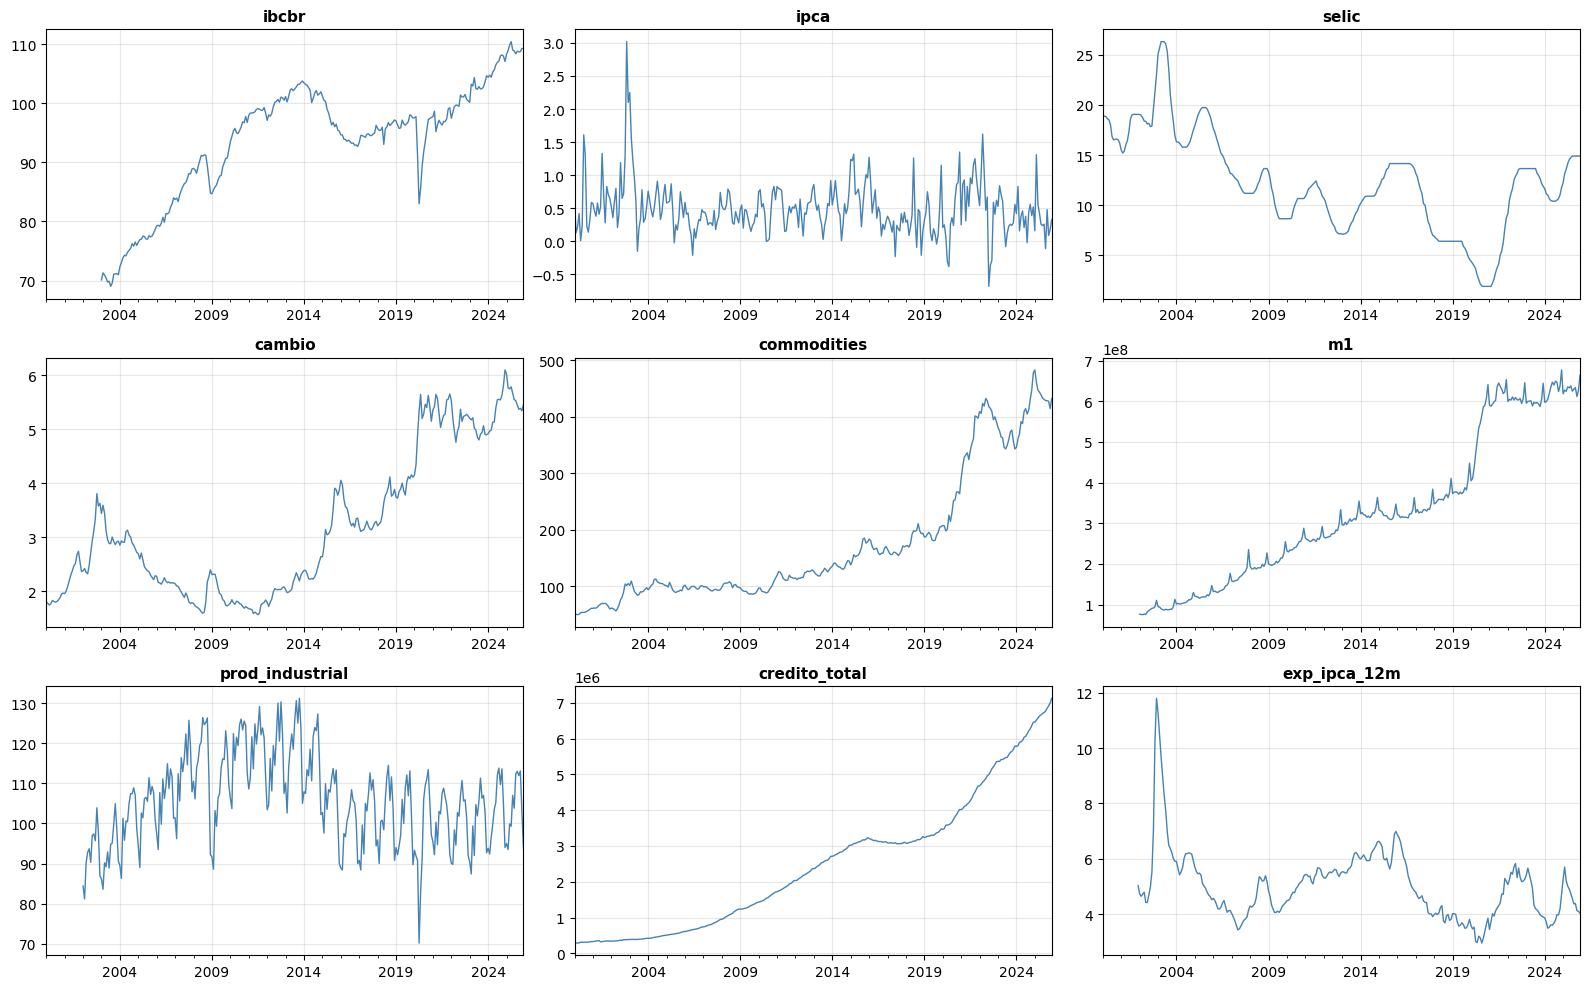

In [5]:
# Plot de todas as séries em uma grade
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10))
axes = axes.flatten()  # transforma matriz 3x3 em vetor de 9 eixos

cols = df.columns.tolist()
for i, col in enumerate(cols):
    ax = axes[i]
    df[col].plot(ax=ax, color='steelblue', linewidth=1)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/01_series_nivel.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.1 IBC-Br (proxy do PIB mensal)

Tendência crescente clara ao longo de todo o período. A queda em 2020-Q2 (pandemia) 
é a anomalia mais óbvia da série, com recuperação em formato de "V" — em 2021 o nível 
já havia voltado ao patamar pré-pandemia. A série já vem dessazonalizada da fonte 
(BCB SGS 24364 é a versão *seasonally adjusted*), o que se confirma visualmente pela 
ausência de padrão sazonal regular.

### 2.2 IPCA (inflação mensal)

Aparenta estacionariedade em nível, com média estável próxima de 0,5% ao mês. Dois 
episódios merecem destaque:

- **2002-2003**: pico positivo associado à "crise de credibilidade" que precedeu a 
  primeira eleição de Lula, com desancoragem de expectativas, fuga de capitais e 
  pressão cambial repassada a preços.
- **2021-2022**: pico positivo expressivo, com inflação mensal superando 1% diversas 
  vezes. Combinação de choques de oferta (gargalos pós-pandemia), choque de 
  commodities (energia, alimentos), e desvalorização cambial.

A volatilidade do IPCA também parece aumentar em 2020-2022, o que pode demandar 
tratamento ou consideração em modelos com heterocedasticidade condicional.

### 2.3 Selic (taxa básica de juros)

Ciclos visíveis de aperto e afrouxamento monetário. O nível médio caiu ao longo do 
período — de patamares próximos a 20% no início dos anos 2000 para mínimos históricos 
em 2020-2021 (cerca de 2% a.a.) — refletindo a consolidação do regime de metas e a 
queda da inflação estrutural.

**Atenção conceitual:** essa queda do nível médio não é uma "tendência" no sentido 
estatístico (componente não-estacionário que se prolongaria indefinidamente), mas 
sim uma transição entre regimes macroeconômicos. Para o teste ADF, isso pode gerar 
não-rejeição da hipótese nula mesmo quando a série é estacionária por partes — ponto 
a observar no Bloco 4.

### 2.4 Câmbio (R$/US$)

Tendência de depreciação cambial ao longo do período, com episódios marcantes de 
estresse:

- 2002: crise pré-Lula
- 2008-2009: crise financeira global
- 2015-2016: recessão Dilma e choque político
- 2020: pandemia

O regime cambial parece distinto antes e depois de 2014: até essa data o câmbio 
oscilava em torno de R$ 2,00-3,00; após 2014 estabiliza-se em patamares acima de 
R$ 4,00, refletindo fim do superciclo de commodities e mudança no balanço de pagamentos.

### 2.5 IC-Br (índice de commodities BCB em BRL)

Comportamento relativamente estável até 2019, com leve tendência de alta. A partir 
de 2020 há **disparo expressivo**, com o índice mais que dobrando entre 2020 e 2022. 
Reflete combinação de: (i) choques globais de preços de commodities pós-pandemia, 
(ii) desvalorização cambial (o índice está em BRL, então depreciação do real amplifica 
preços em moeda nacional), (iii) guerra Rússia-Ucrânia em 2022.

### 2.6 M1 (agregado monetário)

Tendência clara de crescimento, com **sazonalidade visualmente evidente**: picos 
recorrentes em fim de ano, explicados pela injeção de liquidez via 13º salário, PLR 
e bônus de fim de ano. Salto expressivo de nível em 2020, refletindo as medidas de 
expansão monetária e fiscal durante a pandemia (auxílio emergencial, medidas de 
preservação do emprego, crédito extraordinário).

**Tratamento necessário:** dessazonalização via X-13 ARIMA-SEATS.

### 2.7 Produção industrial

Série com **sazonalidade densa e óbvia** (oscilações regulares dentro de cada ano) 
e **mudança de regime de volatilidade em 2014-2015**: antes desse período a produção 
oscilava em patamar mais elevado (95-130); depois cai para faixa menor (85-115), 
refletindo a estagnação industrial conhecida como "década perdida" da indústria 
brasileira. Queda dramática em 2020-Q2 e recuperação parcial.

**Tratamento necessário:** dessazonalização via X-13 ARIMA-SEATS. A mudança de regime 
de volatilidade pode justificar análise de robustez restringindo o modelo ao período 
pós-2015.

### 2.8 Crédito total

Tendência forte e suave de crescimento. Possíveis inflexões a investigar:

- **2007-2008**: aceleração consistente com o boom de crédito consignado e expansão 
  do BNDES no período pré-crise.
- **2015-2016**: desaceleração compatível com a recessão e mudanças no marco do 
  crédito direcionado.

A magnitude expressiva (R$ 7 trilhões em 2025) e o crescimento sustentado refletem 
tanto evolução real quanto efeito de inflação acumulada. Em log + diferenciação 
(Bloco 4), o crescimento real fica isolado.

### 2.9 Expectativa de inflação 12 meses (Focus)

Série bem comportada após o término da crise de 2002-2003. Pico isolado em 2002-2003 
(desancoragem pré-Lula) destoa fortemente do restante. **Observação importante:** 
no período pós-pandemia, as expectativas subiram em 2021-2022 e depois recuaram, mas 
**não voltaram ao nível 2017-2019**. Esse fenômeno de desancoragem parcial das 
expectativas é tema central no debate macroeconômico brasileiro de 2024-2025.

A inclusão desta série é a principal novidade metodológica em relação à monografia 
original. A expectativa de inflação é o principal candidato a resolver o *price puzzle* 
identificado no trabalho anterior.

## 3. Síntese e implicações para o tratamento

| Série | Sazonalidade | Tendência forte | Quebra estrutural | Tratamento |
|-------|:------------:|:---------------:|:-----------------:|------------|
| ibcbr | ❌ (já SA) | ✅ | Pandemia (2020) | Dummy COVID + log + diff |
| ipca | A verificar | ❌ | Crise 2002, COVID | Dummy COVID; truncar 2003? |
| selic | ❌ | Mudança de regime | Diversos ciclos | Diff (provavelmente) |
| cambio | A verificar | ✅ | 2014, COVID | Dummy COVID + log + diff |
| commodities | A verificar | ✅ pós-2020 | 2020 (disparo) | Dummy COVID + log + diff |
| m1 | ✅ óbvia | ✅ | COVID | X-13 + log + diff |
| prod_industrial | ✅ óbvia | Mudança 2014-15 | COVID | X-13 + dummy COVID + diff |
| credito_total | A verificar | ✅ | 2007-08, 2015-16 | X-13? + log + diff |
| exp_ipca_12m | A verificar | ❌ pós-2003 | 2002-03, 2020-22 | Dummy COVID; truncar 2003 |

**Decisões consolidadas para os próximos passos:**

1. **Janela do modelo principal**: 2003-01 a 2025-12 (limitada pelo início do IBC-Br)
2. **Janela de robustez**: 2005-01 a 2025-12 (exclui resíduos da crise 2002-2003)
3. **Pandemia**: dummies mensais para o período de maior distorção (provavelmente 
   2020-03 a 2020-09, a refinar)
4. **Dessazonalização**: aplicação obrigatória em `m1` e `prod_industrial`; 
   verificação por X-13 em `commodities`, `credito_total` e `cambio`
5. **Transformações log**: aplicadas a séries em níveis com tendência forte 
   (ibcbr, cambio, commodities, m1, prod_industrial, credito_total)
6. **Quebras estruturais**: a investigar formalmente no Bloco 4 via testes de 
   Bai-Perron ou Zivot-Andrews